# Load Images

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Se han seleccionado 2000 imágenes de outfits para procesar.
✅ Se han encontrado 46 imágenes listas para procesar de prendas.


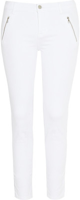

In [2]:
import glob
import random
from PIL import Image

# Ponemos la ruta exacta de tu carpeta
ruta_outfits = "/content/drive/MyDrive/Máster/Deep Learning II/Dathaton/Data/Outfits"
ruta_prendas_sueltas = "/content/drive/MyDrive/Máster/Deep Learning II/Dathaton/Data/Prendas sueltas"

# Buscamos todas las imágenes .jpg y .png que tengas ahí sueltas
outfits = glob.glob(f"{ruta_outfits}/*.jpg") + glob.glob(f"{ruta_outfits}/*.png")
prendas = glob.glob(f"{ruta_prendas_sueltas}/*.jpg") + glob.glob(f"{ruta_prendas_sueltas}/*.png")

# ==========================================
# ✂️ RECORTE DE IMÁGENES (NUEVO)
# ==========================================
# 1. Barajamos la lista para que la muestra sea aleatoria y variada
random.shuffle(outfits)

# 2. Nos quedamos solo con las primeras 4000 de esa lista barajada
outfits = outfits[:2000]
# ==========================================

print(f"✅ Se han seleccionado {len(outfits)} imágenes de outfits para procesar.")
print(f"✅ Se han encontrado {len(prendas)} imágenes listas para procesar de prendas.")

# Podemos ver la primera foto para comprobar que carga bien
if outfits and prendas: # Cambié esto ligeramente para que no dé error si las listas están vacías
    img_prueba = Image.open(prendas[0])
    img_prueba.thumbnail((200, 200)) # La hacemos pequeñita para visualizarla
    display(img_prueba)
else:
    print("No se han encontrado fotos. Revisa que la ruta sea correcta.")

# Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


def plot_tsne_embeddings(embeddings_dict, title_prefix):
    """
    Performs t-SNE dimensionality reduction and visualizes the embeddings in a scatter plot.

    Args:
        embeddings_dict (dict): A dictionary with image names as keys and high-dimensional embeddings as values.
        title_prefix (str): A string to prepend to the plot title (e.g., "ViT", "ResNet-50").
    """
    image_names = list(embeddings_dict.keys())
    embeddings_array = np.array(list(embeddings_dict.values()))

    # t-SNE requires n_samples > 1 and perplexity < n_samples
    n_samples = len(image_names)
    if n_samples <= 1:
        print(f"Warning: Cannot perform t-SNE with {n_samples} samples. Need at least 2 samples.")
        return {}

    # Set perplexity to a valid value: max(1, min(n_samples - 1, 30))
    perplexity_val = max(1, min(n_samples - 1, 30))
    if n_samples < 3:
        print(f"Warning: Perplexity set to {perplexity_val} for t-SNE due to small sample size (n_samples={n_samples}).")

    tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=42, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(embeddings_array)

    print(f"Original {title_prefix} embedding shape: {embeddings_array.shape}")
    print(f"Reduced {title_prefix} embedding shape (2D): {embeddings_2d.shape}")
    print(f"2D {title_prefix} embeddings generated successfully using t-SNE.")

    embeddings_2d_dict = {name: emb_2d for name, emb_2d in zip(image_names, embeddings_2d)}

    plt.figure(figsize=(8, 6))
    for name, emb_2d in embeddings_2d_dict.items():
        plt.scatter(emb_2d[0], emb_2d[1], label=name)

    plt.title(f'{title_prefix} Image Embeddings Reduced to 2D (t-SNE)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

    return embeddings_2d_dict

def plot_similarity_heatmap(embeddings_dict, title_prefix):
    """
    Calculates cosine similarity matrix and visualizes it as a heatmap.

    Args:
        embeddings_dict (dict): A dictionary with image names as keys and high-dimensional embeddings as values.
        title_prefix (str): A string to prepend to the plot title (e.g., "ViT", "ResNet-50").
    """
    image_names_ordered = list(embeddings_dict.keys())
    embeddings_list = [embeddings_dict[name] for name in image_names_ordered]

    embeddings_matrix = np.array(embeddings_list)

    similarity_matrix = cosine_similarity(embeddings_matrix)

    df_similarity = pd.DataFrame(
        similarity_matrix,
        index=image_names_ordered,
        columns=image_names_ordered
    )

    print(f"{title_prefix} Cosine Similarity Matrix:")
    display(df_similarity)

    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(df_similarity, dtype=bool))
    sns.heatmap(df_similarity, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, mask=mask)
    plt.title(f'{title_prefix} Cosine Similarity Matrix of Image Embeddings (Lower Triangle)')
    plt.show()

    return df_similarity

# ViT Embeddings

In [4]:
'''
from transformers import ViTImageProcessor, ViTModel
import torch

# Load pre-trained ViT model and processor
model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)

print(f"Successfully loaded image processor: {processor.__class__.__name__}")
print(f"Successfully loaded pre-trained model: {model.__class__.__name__}")
'''

'\nfrom transformers import ViTImageProcessor, ViTModel\nimport torch\n\n# Load pre-trained ViT model and processor\nmodel_name = "google/vit-base-patch16-224-in21k"\nprocessor = ViTImageProcessor.from_pretrained(model_name)\nmodel = ViTModel.from_pretrained(model_name)\n\nprint(f"Successfully loaded image processor: {processor.__class__.__name__}")\nprint(f"Successfully loaded pre-trained model: {model.__class__.__name__}")\n'

In [5]:
'''
import torch
from PIL import Image
import os

# Diccionario donde guardaremos los resultados (el que luego le pasarás a tus funciones de visualización)
image_embeddings_vit = {}

# 1. Configurar la GPU (¡Esto multiplicará la velocidad!)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval() # Modo evaluación (apaga capas como Dropout)

print(f"🚀 Iniciando extracción usando: {device.upper()}")

# 2. Iterar sobre las rutas de tu Drive (usamos 'rutas_fotos' del paso anterior)
for ruta in outfits:
    try:
        # Extraer el nombre del archivo (ej: "falda_amarilla.jpg")
        name = os.path.basename(ruta)

        # Cargar imagen y asegurar formato RGB
        img = Image.open(ruta).convert("RGB")

        # Preprocesar imagen y enviarla a la GPU/CPU
        inputs = processor(images=img, return_tensors="pt").to(device)

        # Generar embeddings
        with torch.no_grad():
            outputs = model(**inputs)

            # TU LÓGICA: Obtener el estado oculto (token CLS en la posición 0)
            embeddings = outputs.last_hidden_state[:, 0, :].squeeze()

        # Guardar como NumPy array en el diccionario
        image_embeddings_vit[name] = embeddings.cpu().numpy()

    except Exception as e:
        print(f"⚠️ Error procesando {ruta}: {e}")

print("\n--- Verificación rápida ---")
# Mostrar los primeros 5 elementos de las 3 primeras imágenes para no saturar la pantalla
for name, embedding in list(image_embeddings_vit.items())[:3]:
    print(f"Embedding para {name}: {embedding[:5]}...")
'''

'\nimport torch\nfrom PIL import Image\nimport os\n\n# Diccionario donde guardaremos los resultados (el que luego le pasarás a tus funciones de visualización)\nimage_embeddings_vit = {}\n\n# 1. Configurar la GPU (¡Esto multiplicará la velocidad!)\ndevice = "cuda" if torch.cuda.is_available() else "cpu"\nmodel.to(device)\nmodel.eval() # Modo evaluación (apaga capas como Dropout)\n\nprint(f"🚀 Iniciando extracción usando: {device.upper()}")\n\n# 2. Iterar sobre las rutas de tu Drive (usamos \'rutas_fotos\' del paso anterior)\nfor ruta in outfits:\n    try:\n        # Extraer el nombre del archivo (ej: "falda_amarilla.jpg")\n        name = os.path.basename(ruta)\n\n        # Cargar imagen y asegurar formato RGB\n        img = Image.open(ruta).convert("RGB")\n\n        # Preprocesar imagen y enviarla a la GPU/CPU\n        inputs = processor(images=img, return_tensors="pt").to(device)\n\n        # Generar embeddings\n        with torch.no_grad():\n            outputs = model(**inputs)\n\n   

In [6]:
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image
import os

# 1. Cargar FashionCLIP
model_name = "patrickjohncyh/fashion-clip"
clip_processor = CLIPProcessor.from_pretrained(model_name)
clip_model = CLIPModel.from_pretrained(model_name)

# Configurar GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model.to(device)
clip_model.eval()

print(f"👗 FashionCLIP cargado. Extrayendo usando: {device.upper()}")

# Diccionario para guardar los resultados
image_embeddings_fashion = {}

# 2. Iterar sobre las rutas
for ruta in outfits:
    try:
        name = os.path.basename(ruta)
        img = Image.open(ruta).convert("RGB")

        # Preprocesar la imagen
        inputs = clip_processor(images=img, return_tensors="pt").to(device)

        # 3. Generar embeddings
        with torch.no_grad():
            outputs = clip_model.get_image_features(**inputs)

            # EXTRAEMOS EL VECTOR DEL OBJETO
            embeddings = outputs.pooler_output

        # Guardar en el diccionario
        image_embeddings_fashion[name] = embeddings.squeeze().cpu().numpy()

    except Exception as e:
        print(f"⚠️ Error procesando {ruta}: {e}")

print("\n✅ ¡Extracción completada con FashionCLIP!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


👗 FashionCLIP cargado. Extrayendo usando: CUDA

✅ ¡Extracción completada con FashionCLIP!


RESULTADOS

🔎 Buscando outfits para: '100167523_1.jpg' (+ texto: 'neckalce')


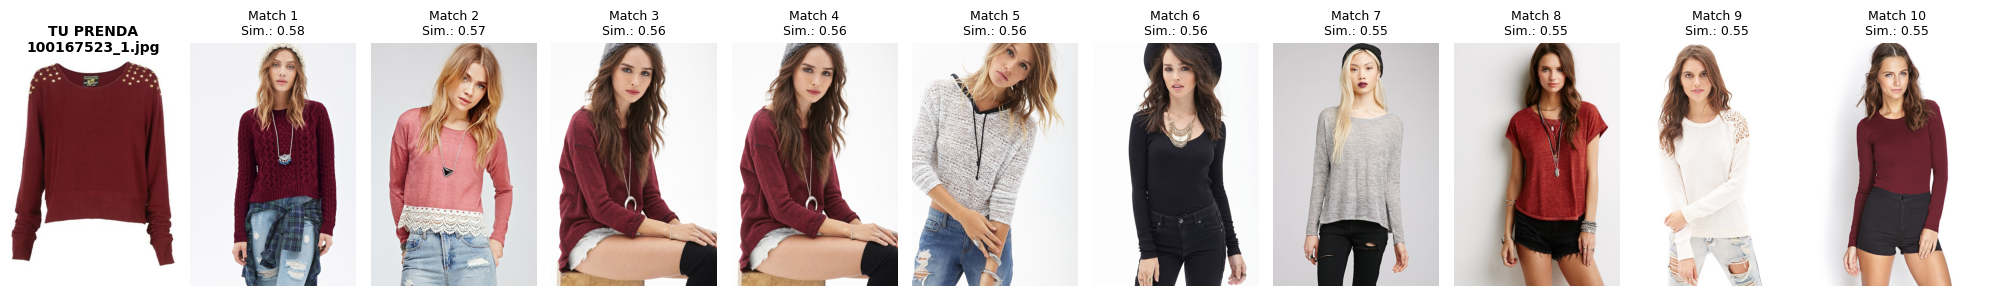

In [21]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import numpy as np

# ==========================================
# 1. PREPARAR LA IMAGEN NUEVA (Query)
# ==========================================
fotos_query = glob.glob(f"{ruta_prendas_sueltas}/*.jpg") + glob.glob(f"{ruta_prendas_sueltas}/*.png")

if not fotos_query:
    print("⚠️ No se han encontrado imágenes en ruta_prendas_sueltas")
else:
    ruta_query_actual = fotos_query[4]
    nombre_query = os.path.basename(ruta_query_actual)
    img_query = Image.open(ruta_query_actual).convert("RGB")

    # ==========================================
    # 2. PASAR LA FOTO NUEVA Y EL TEXTO POR FASHIONCLIP
    # ==========================================

    # 2.1 Vector de IMAGEN
    inputs_img = clip_processor(images=img_query, return_tensors="pt").to(device)
    with torch.no_grad():
        out_img = clip_model.get_image_features(**inputs_img)
        # Extraemos el tensor y aseguramos que sea 1D [512]
        vector_imagen = out_img.pooler_output.squeeze()

    # 2.2 Vector de TEXTO
    texto_guia = "neckalce"
    inputs_txt = clip_processor(text=[texto_guia], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out_txt = clip_model.get_text_features(**inputs_txt)

        # Extracción a prueba de balas para el texto
        if isinstance(out_txt, torch.Tensor):
            vector_texto = out_txt.squeeze()
        elif hasattr(out_txt, 'pooler_output'):
            vector_texto = out_txt.pooler_output.squeeze()
        elif hasattr(out_txt, 'text_embeds'):
            vector_texto = out_txt.text_embeds.squeeze()
        else:
            # Por si acaso fuera otra variante de la arquitectura
            vector_texto = out_txt.last_hidden_state[:, 0, :].squeeze()

    # 2.3 FUSIÓN: Sumamos ambos vectores (50/50)
    # Ahora ambos son [512], la suma da [512]
    query_embedding = (vector_imagen + vector_texto) / 2

    # Añadimos la dimensión de batch para la multiplicación [1, 512]
    query_embedding = query_embedding.unsqueeze(0)

    # ==========================================
    # 3. CALCULAR LA SIMILITUD
    # ==========================================

    # 3.1 Dataset: Convertimos primero a numpy array para evitar el Warning de lentitud
    nombres_fotos = list(image_embeddings_fashion.keys())
    embeddings_np = np.array(list(image_embeddings_fashion.values()))
    dataset_embeddings = torch.from_numpy(embeddings_np).to(device)

    # 3.2 Normalización
    query_embedding = query_embedding / query_embedding.norm(dim=-1, keepdim=True)
    dataset_embeddings_norm = dataset_embeddings / dataset_embeddings.norm(dim=-1, keepdim=True)

    # 3.3 Similitud del Coseno
    # Resultado esperado: [1, N_fotos] -> .flatten() para tener una lista simple
    similitudes = (query_embedding @ dataset_embeddings_norm.T).flatten()

    # 3.4 Extraer el Top 10
    top_k = min(10, len(nombres_fotos))
    valores, indices = torch.topk(similitudes, top_k)

    # ==========================================
    # 4. VISUALIZAR: FOTO NUEVA VS OUTFITS
    # ==========================================
    print(f"🔎 Buscando outfits para: '{nombre_query}' (+ texto: '{texto_guia}')")

    fig, axes = plt.subplots(1, top_k + 1, figsize=(20, 5))

    # Mostrar la prenda suelta (Query)
    axes[0].imshow(img_query)
    axes[0].set_title(f"TU PRENDA\n{nombre_query}", fontweight="bold", fontsize=10)
    axes[0].axis('off')

    # Mostrar resultados
    for i in range(top_k):
        # Ahora accedemos a los índices de forma segura
        idx = indices[i].item()
        nombre_match = nombres_fotos[idx]
        score = valores[i].item()

        ruta_match = os.path.join(ruta_outfits, nombre_match)

        try:
            img_match = Image.open(ruta_match)
            axes[i + 1].imshow(img_match)
            axes[i + 1].set_title(f"Match {i+1}\nSim.: {score:.2f}", fontsize=9)
        except:
            axes[i + 1].text(0.5, 0.5, "Error carga", ha='center')

        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()